# AAPL Beta Estimation — CAPM Regression

This notebook estimates Apple's **market beta** by regressing AAPL monthly returns against SPY (S&P 500 ETF) monthly returns.

### What are we measuring?
- **Alpha** (intercept): AAPL's excess return when the market return is 0% — persistent alpha suggests outperformance beyond market exposure
- **Beta** (slope): how much AAPL moves for every 1% move in the market — beta > 1 means more volatile than the market
- **R-squared**: what fraction of AAPL's monthly moves are explained by the market
- **Residual SE**: the idiosyncratic (stock-specific) risk not explained by SPY

## 1. Import Libraries

In [1]:
import pandas as pd                          # data manipulation and DataFrames
from datetime import date                   # dynamic date range
import yfinance as yf                       # Yahoo Finance price data
import numpy as np                          # numerical operations
import matplotlib.pyplot as plt             # base plotting library
from matplotlib.ticker import PercentFormatter  # format axes as percentages
import seaborn as sns                       # statistical visualisations
import statsmodels.formula.api as smf       # R-style OLS formula API
from statsmodels.stats.anova import anova_lm    # ANOVA decomposition
from scipy import stats                     # probplot for Q-Q panel

## 2. Helper Function: `fit_and_plot`

Fits an OLS model and produces a 3-panel diagnostic plot:
- **Top**: actual vs predicted (x = primary predictor)
- **Bottom-left**: residuals vs fitted
- **Bottom-right**: Q-Q plot of residuals

The key fix vs naive implementations: `model_data = data.loc[model.fittedvalues.index]` ensures we only plot rows the model actually used, avoiding size-mismatch errors when NaNs are present.

In [2]:
def fit_and_plot(formula, data, model_name="Model", x_var=None):
    model = smf.ols(formula=formula, data=data).fit()  # fit OLS
    print(model.summary())                              # full statsmodels output

    # infer x_var from the formula if not supplied
    if x_var is None:
        x_var = formula.split('~')[1].strip().split('+')[0].strip()

    y_var     = formula.split('~')[0].strip()   # outcome variable name
    residuals = model.resid                      # actual minus fitted

    # CRITICAL: use only rows the model fitted on (drops NaN rows automatically)
    model_data = data.loc[model.fittedvalues.index]

    is_cat = model_data[x_var].dtype == object or str(model_data[x_var].dtype) == 'category'

    fig = plt.figure(figsize=(15, 10))
    gs  = fig.add_gridspec(2, 2, height_ratios=[1.6, 1], hspace=0.35, wspace=0.3)
    ax_main = fig.add_subplot(gs[0, :])   # top panel -- full width
    ax_res  = fig.add_subplot(gs[1, 0])   # bottom-left
    ax_qq   = fig.add_subplot(gs[1, 1])   # bottom-right

    # --- Panel 1: Actual vs Predicted ---
    if is_cat:
        sns.stripplot(x=model_data[x_var], y=model_data[y_var],
                      alpha=0.3, color='black', s=4, ax=ax_main, label='Actual')
        group_means = model_data.groupby(x_var)[y_var].mean()
        ax_main.hlines(group_means.values,
                       xmin=[i - 0.3 for i in range(len(group_means))],
                       xmax=[i + 0.3 for i in range(len(group_means))],
                       colors='red', linewidth=2, label='Predicted mean')
    else:
        # .values avoids index-mismatch issues with matplotlib
        ax_main.scatter(model_data[x_var].values, model_data[y_var].values,
                        alpha=0.3, color='black', s=15, label='Actual')
        ax_main.scatter(model_data[x_var].values, model.fittedvalues.values,
                        alpha=0.3, color='red', s=15, label='Predicted')

    ax_main.set_title(f'Actual vs Predicted -- x: {x_var}', fontsize=13)
    ax_main.set_xlabel(x_var)
    ax_main.set_ylabel(y_var)
    ax_main.legend()

    # --- Panel 2: Residuals vs Fitted ---
    ax_res.scatter(model.fittedvalues, residuals, alpha=0.3, color='steelblue', s=15)
    ax_res.axhline(0, color='red', linewidth=1, linestyle='--')  # zero reference line
    ax_res.set_title('Residuals vs Fitted', fontsize=11)
    ax_res.set_xlabel('Fitted Values')
    ax_res.set_ylabel('Residuals')

    # --- Panel 3: Q-Q Plot ---
    (osm, osr), (slope, intercept, _) = stats.probplot(residuals, dist='norm')
    ax_qq.scatter(osm, osr, alpha=0.3, color='steelblue', s=15)
    ax_qq.plot(osm, slope * np.array(osm) + intercept,
               color='red', linewidth=1, linestyle='--')  # theoretical normal line
    ax_qq.set_title('Q-Q Plot of Residuals', fontsize=11)
    ax_qq.set_xlabel('Theoretical Quantiles')
    ax_qq.set_ylabel('Sample Quantiles')

    plt.suptitle(f'{model_name}  |  R2 = {model.rsquared:.3f}  |  Adj R2 = {model.rsquared_adj:.3f}',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

    return model  # return so we can extract alpha, beta, etc. afterwards

print("fit_and_plot() defined.")

fit_and_plot() defined.


## 3. Download Price Data

We download 5 years of **adjusted close** prices for AAPL and SPY from Yahoo Finance.
Adjusted prices account for dividends and stock splits -- essential for accurate return calculations.

In [3]:
tickers_to_download = ['AAPL', 'SPY']  # Apple + S&P 500 ETF as market benchmark

end_date   = date.today()                         # today's date dynamically
start_date = date(end_date.year - 5, 1, 1)        # 5 years of history

print(f"Downloading {tickers_to_download} from {start_date} to {end_date}...")

adj_close_df = yf.download(
    tickers_to_download,
    start=start_date,
    end=end_date,
    auto_adjust=False,   # keep raw prices so we can explicitly select Adj Close
    progress=True        # show download progress bar
)['Adj Close']           # select only the adjusted close price column

print(f"Downloaded. Shape: {adj_close_df.shape}")
adj_close_df.head()

[*********************100%***********************]  2 of 2 completed

Downloaded. Shape: (1308, 2)


Ticker,AAPL,SPY
Date,,
2021-01-04,125.856720,344.256744
2021-01-05,127.412758,346.627747
2021-01-06,123.123863,348.700073
2021-01-07,127.325241,353.880859
2021-01-08,128.424210,355.897278


## 4. Compute Monthly Returns

Daily prices are too noisy for beta estimation. We resample to **month-end prices** and compute percentage changes.

1. `.resample('M').last()` — take the last trading day price each month
2. `.pct_change()` — month-over-month return
3. `.dropna()` — remove the first row (no prior month to compare against)

In [5]:
monthly_returns = (
    adj_close_df
    .resample('ME').last()   # month-end prices
    .pct_change()           # month-over-month % change = monthly return
    .dropna()               # drop first row (NaN -- no prior month)
)

print(f"Monthly returns shape: {monthly_returns.shape}")
print(f"Date range: {monthly_returns.index[0].date()} to {monthly_returns.index[-1].date()}")
monthly_returns.head()

Monthly returns shape: (62, 2)
Date range: 2021-02-28 to 2026-03-31


Ticker,AAPL,SPY
Date,,
2021-02-28,-0.079712,0.027805
2021-03-31,0.007340,0.045399
2021-04-30,0.076218,0.052911
2021-05-31,-0.050497,0.006566
2021-06-30,0.099109,0.022428


## 5. Fit CAPM Regression

We fit: **AAPL Return = Alpha + Beta × SPY Return + error**

Using `fit_and_plot` gives us the full model summary plus the 3-panel diagnostic plot in one call.

                            OLS Regression Results                            
Dep. Variable:                   AAPL   R-squared:                       0.451
Model:                            OLS   Adj. R-squared:                  0.442
Method:                 Least Squares   F-statistic:                     49.34
Date:                Fri, 20 Mar 2026   Prob (F-statistic):           2.27e-09
Time:                        20:46:50   Log-Likelihood:                 95.517
No. Observations:                  62   AIC:                            -187.0
Df Residuals:                      60   BIC:                            -182.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0007      0.007      0.100      0.9

/var/folders/92/b0mp0v8546x1_h0np6ymywd80000gp/T/ipykernel_29026/155321946.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


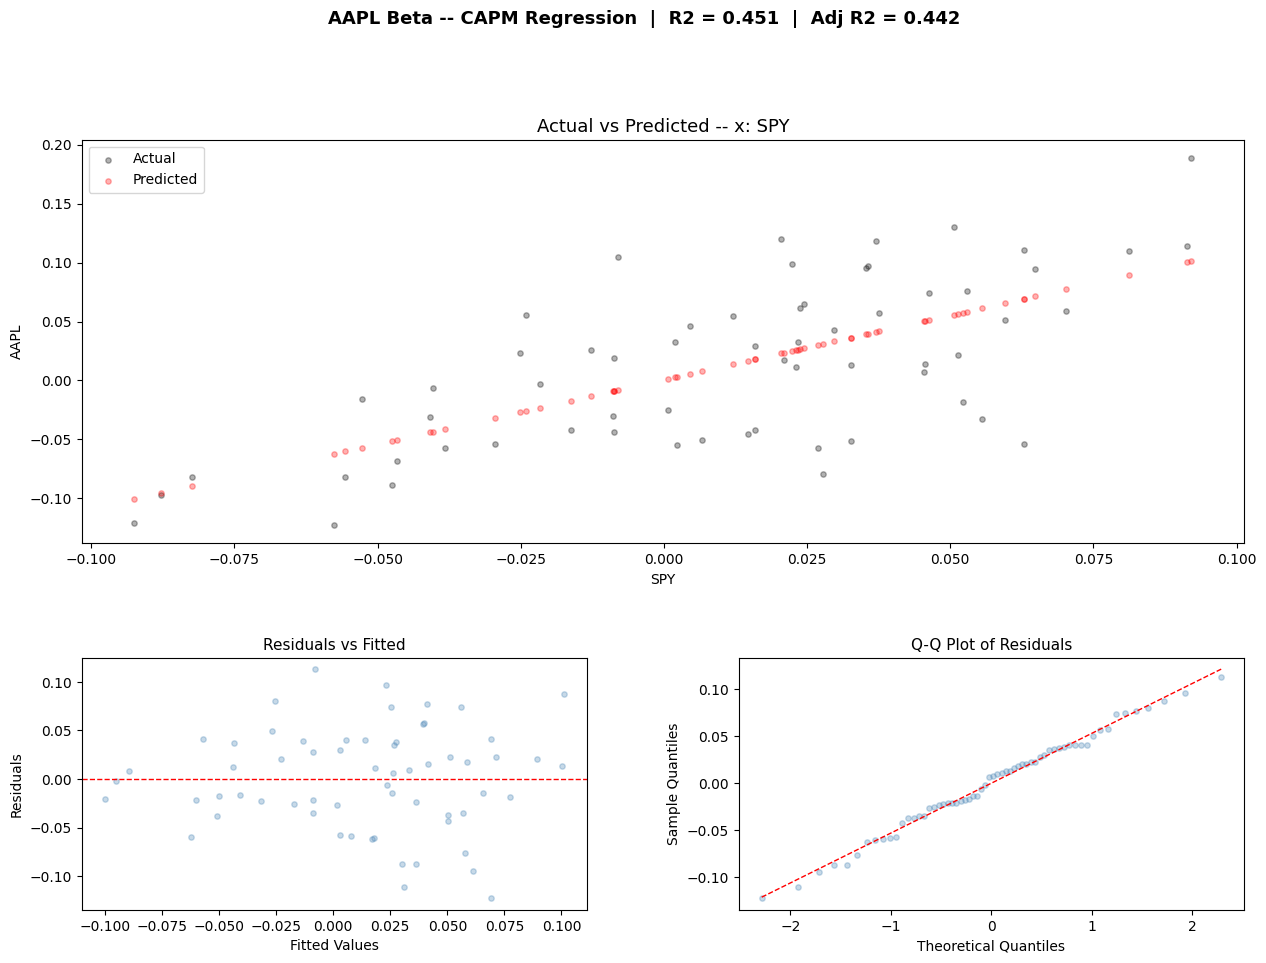

In [6]:
# Fit AAPL ~ SPY and produce the 3-panel diagnostic plot
model = fit_and_plot(
    formula='AAPL ~ SPY',          # CAPM regression: stock return ~ market return
    data=monthly_returns,
    model_name='AAPL Beta -- CAPM Regression',
    x_var='SPY'                    # market return on x-axis of the top panel
)

## 6. Extract & Interpret Key Statistics

In [7]:
# Extract the four key numbers from the fitted model
alpha        = model.params['Intercept']   # monthly alpha: excess return when market = 0
beta         = model.params['SPY']         # beta: sensitivity to market movements
r_squared    = model.rsquared              # % of AAPL variance explained by SPY
residual_se  = model.scale ** 0.5          # idiosyncratic (stock-specific) risk

print("--- Key Statistics ---")
print(f"Alpha (monthly):  {alpha:.4f}  ({alpha*12:.2%} annualised)")
print(f"Beta:             {beta:.4f}")
print(f"R-squared:        {r_squared:.4f}  ({r_squared:.2%} of AAPL moves explained by market)")
print(f"Residual SE:      {residual_se:.4f}  (monthly idiosyncratic risk)")
print()
print("Interpretation:")
if beta > 1:
    print(f"  Beta > 1 ({beta:.2f}): AAPL is MORE volatile than the market.")
elif beta < 1:
    print(f"  Beta < 1 ({beta:.2f}): AAPL is LESS volatile than the market.")
else:
    print(f"  Beta ~ 1 ({beta:.2f}): AAPL moves in line with the market.")

--- Key Statistics ---
Alpha (monthly):  0.0007  (0.83% annualised)
Beta:             1.0912
R-squared:        0.4513  (45.13% of AAPL moves explained by market)
Residual SE:      0.0527  (monthly idiosyncratic risk)

Interpretation:
  Beta > 1 (1.09): AAPL is MORE volatile than the market.


## 7. ANOVA Decomposition

ANOVA splits the total variation in AAPL returns into:
- **Explained** by SPY (market risk)
- **Unexplained** residual (idiosyncratic risk)

Type II sum of squares is used here as it is the standard choice for single-predictor models.

In [9]:
# Type II ANOVA: partitions variance into explained (SPY) and unexplained (residual)
anova_results = anova_lm(model, typ=2)
print("--- ANOVA Decomposition ---")
display(anova_results.round(4))

ss_model    = anova_results.loc['SPY',      'sum_sq']   # variance explained by SPY
ss_residual = anova_results.loc['Residual', 'sum_sq']   # unexplained variance
ss_total    = ss_model + ss_residual                     # total variance

# MSE for each component (divide by degrees of freedom)
mse_model    = ss_model    / anova_results.loc['SPY',      'df']
mse_residual = mse_model   / anova_results.loc['SPY',      'df']   # same as model.mse_resid

# R-squared from first principles: SS_model / SS_total
r2_manual = ss_model / ss_total

print(f"SS Model (SPY):   {ss_model:.4f}")
print(f"SS Residual:      {ss_residual:.4f}")
print(f"SS Total:         {ss_total:.4f}")
print(f"MSE Residual:     {model.mse_resid:.4f}")
print(f"R² manual:        {r2_manual:.4f}")
print(f"R² from model:    {model.rsquared:.4f}  <-- should match")

--- ANOVA Decomposition ---


,sum_sq,df,F,PR(>F)
SPY,0.1370,1.0,49.3409,0.0
Residual,0.1666,60.0,NaN,NaN


SS Model (SPY):   0.1370
SS Residual:      0.1666
SS Total:         0.3037
MSE Residual:     0.0028
R² manual:        0.4513
R² from model:    0.4513  <-- should match


## 8. Scatter Plot with Regression Line

A clean scatter plot of monthly returns with the CAPM regression line overlaid.
This is the classic Security Characteristic Line (SCL) used in finance textbooks.

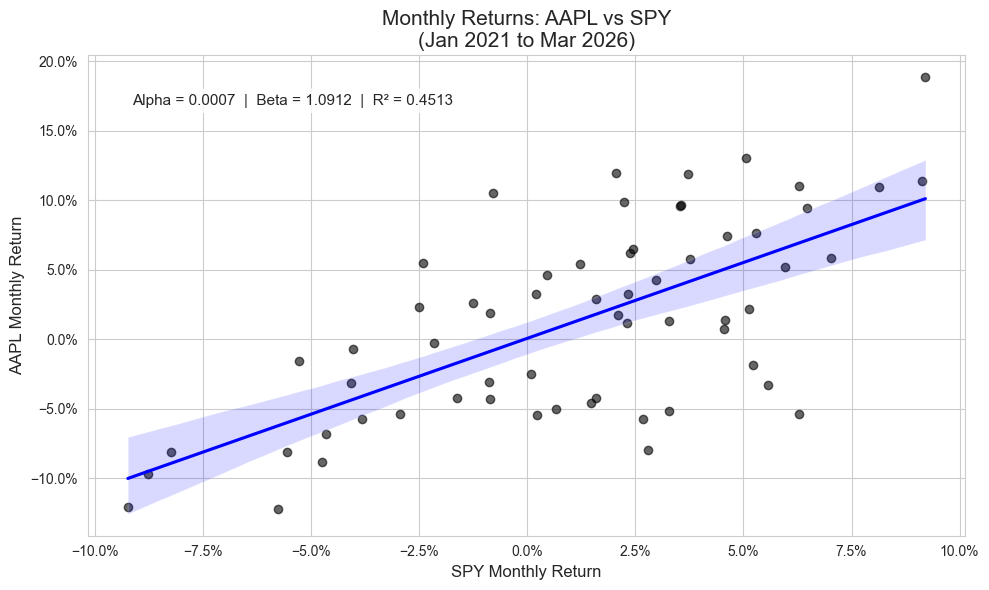

In [13]:
sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(10, 6))

sns.regplot(
    x='SPY',
    y='AAPL',
    data=monthly_returns,
    color='black',
    line_kws={'color': 'blue'},
    scatter_kws={'alpha': 0.6},
    ax=ax
)

ax.xaxis.set_major_formatter(PercentFormatter(xmax=1.0))
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))

ax.text(0.05, 0.92,
        f'Alpha = {alpha:.4f}  |  Beta = {beta:.4f}  |  R² = {r_squared:.4f}',
        transform=ax.transAxes,
        fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_title(
    f'Monthly Returns: AAPL vs SPY\n({start_date.strftime("%b %Y")} to {end_date.strftime("%b %Y")})',
    fontsize=15
)
ax.set_xlabel('SPY Monthly Return', fontsize=12)
ax.set_ylabel('AAPL Monthly Return', fontsize=12)

plt.tight_layout()
plt.show()